# Aufgabe 3
In Aufgabe 3 wurde die Linse von der optischen Bank genommen und der Spalt durch ein Gitter ausgetauscht, so dass nur noch der Laser, die Blende, das Gitter und die CCD-Kamera. In dieser Aufgabe wurde, dass Beugungsbild in Abhängikeit des Abstandes $z$ vom Gitter aufgenommen.

Dabei sollte zuerste wie in den Abbildungne ersichtlich, erst die Peaks des ersten Maximums der FFT ermittelt und dann in ABhängigkeit vom Abstand zum Gitter geplottet.

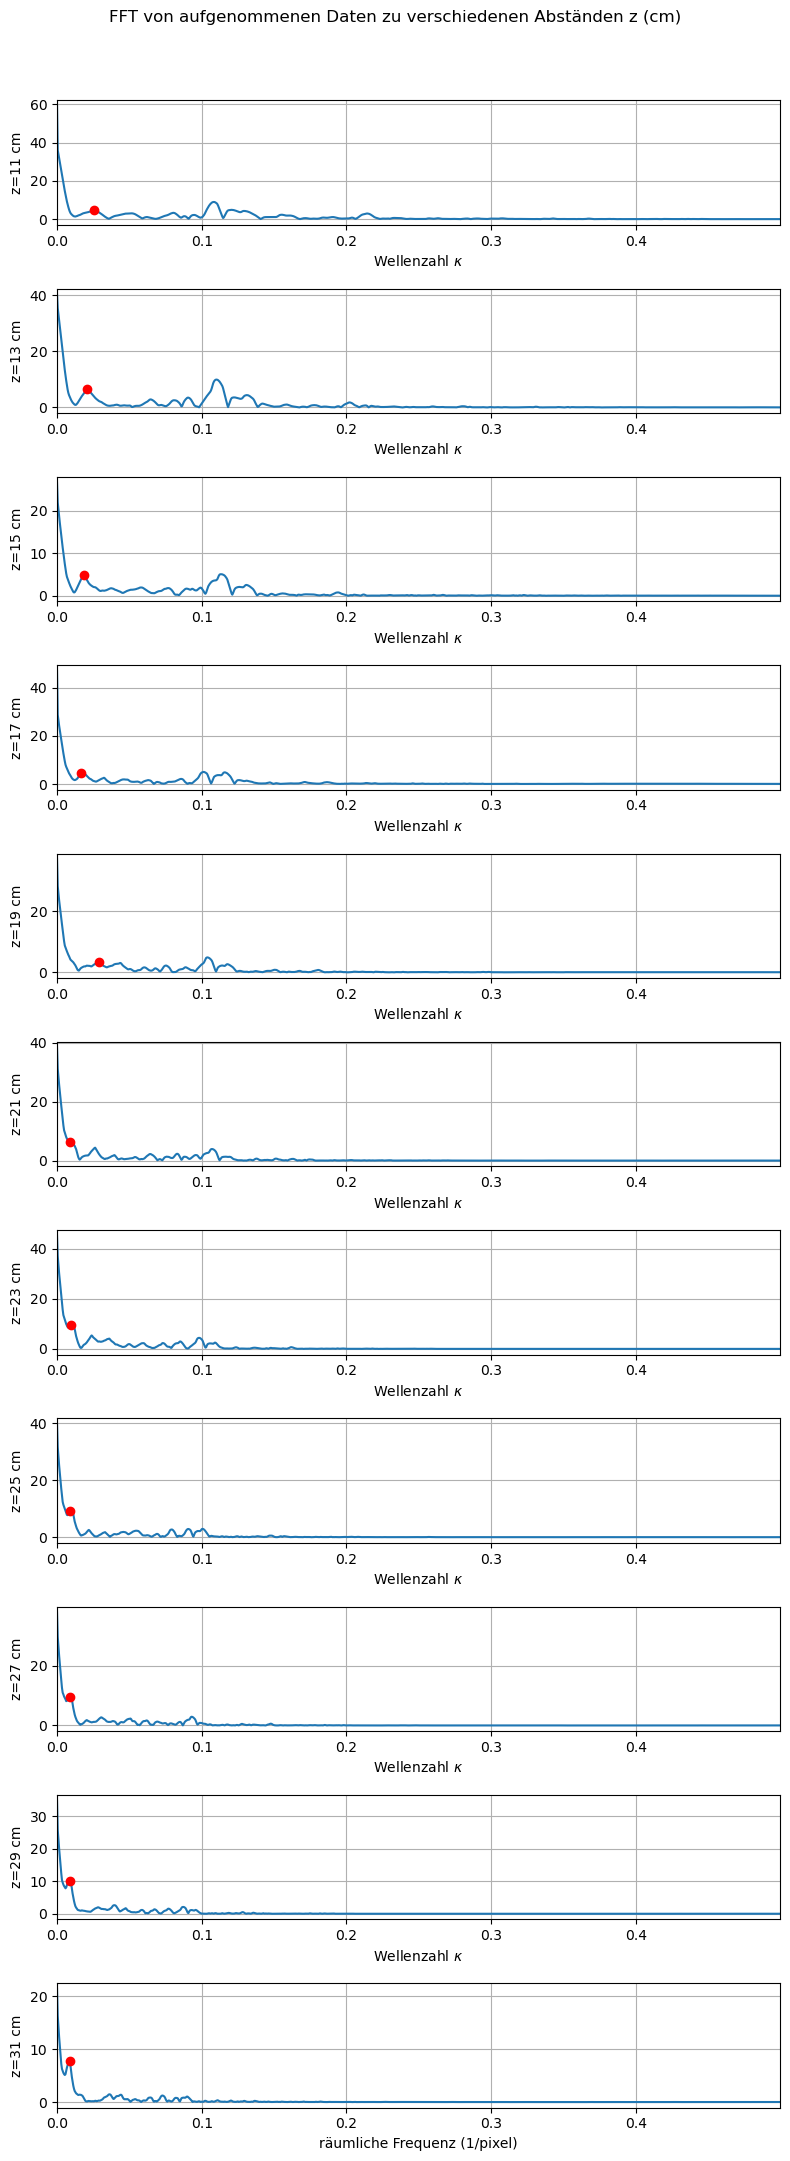

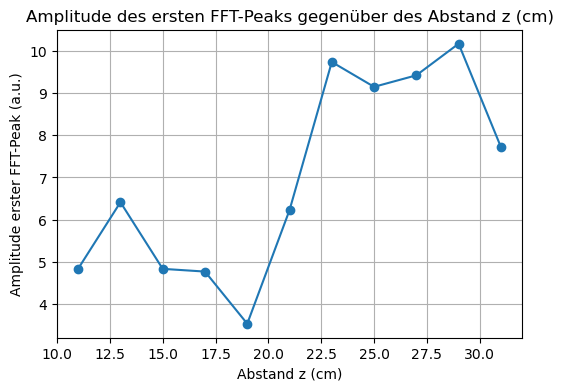

In [32]:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# Positions of the camera on the optical bench (cm) - filenames use these position numbers
_abstand = np.array([47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67])  # positions in cm
# Compute distance from grating to camera: measured position minus grating position at 36 cm -> distances in cm
abstand_cm = _abstand - 36

# Prepare subplots (one per measured position)
Nplots = len(abstand_cm)
fig, axs = plt.subplots(Nplots, 1, figsize=(8, 2 * Nplots))
fig.suptitle("FFT von aufgenommenen Daten zu verschiedenen Abständen z (cm)")

first_order_amplitudes = []
first_order_indices = []
zs = []  # distances in cm (Gitter->Kamera)

for idx, pos in enumerate(_abstand):
    # load data; filenames unchanged and depend on the raw camera position 'pos' (cm)
    df = pd.read_csv(f"./O17 Messdaten/Aufgabe 3/Gitter 1/BeugungGitter{pos}.csv", header=None)
    df.columns = ["pixel", "intensity"]
    intensity = df["intensity"].to_numpy()
    N = len(intensity)

    # FFT and positive half (DC at index 0)
    fy = np.abs(fft(intensity))
    fy_half = fy[: N // 2]
    freqs = fftfreq(N, d=1)[: N // 2]  # unit: 1/pixel

    # peak detection with threshold fallback
    threshold = np.max(fy_half) * 0.08
    peaks, props = find_peaks(fy_half, height=threshold)
    if len(peaks) == 0:
        peaks, props = find_peaks(fy_half)

    peaks = peaks[peaks > 0]
    if len(peaks) == 0:
        peak_idx = np.argmax(fy_half[1:]) + 1
    else:
        peak_idx = peaks.min()

    amp = fy_half[peak_idx]
    first_order_amplitudes.append(amp)
    first_order_indices.append(peak_idx)
    z_cm = pos - 36
    zs.append(z_cm)

    ax = axs[idx] if Nplots > 1 else axs
    ax.plot(freqs, fy_half, label="FFT")
    ax.plot(freqs[peak_idx], fy_half[peak_idx], 'ro', label="1. Peak")
    ax.set_xlim(0, freqs.max())
    ax.set_ylabel(f"z={z_cm} cm")
    ax.set_xlabel("Wellenzahl $\\kappa$")
    ax.grid(True)

plt.xlabel("räumliche Frequenz (1/pixel)")
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Separate plot: amplitude of first peak vs distance in cm
plt.figure(figsize=(6, 4))
plt.plot(zs, first_order_amplitudes, 'o-', linewidth=1.5)
plt.xlabel('Abstand z (cm)')
plt.ylabel('Amplitude erster FFT-Peak (a.u.)')
plt.title('Amplitude des ersten FFT-Peaks gegenüber des Abstand z (cm)')
plt.grid(True)

#print("Gefundene erste Peak-Indizes (positive Hälfte):", first_order_indices)
#print("Abstände z (cm):", zs)
#print("Amplituden (a.u.):", first_order_amplitudes)

# Berechnung der Talbot-Länge

In dieser Zelle wird aus den gemessenen Intensitätsoszillationen der FFT-Erstordnungsamplitude die experimentelle Talbot-Länge bestimmt. Unser vorgehen war dabei wie folgt:

1. Die Amplitude des ersten FFT-Peaks wird als Funktion des Abstands z dargestellt.
2. Die Periodizität dieser Amplituden-Oszillation entspricht der Talbot-Länge. Somit wird die Periodizität aus den Messwerten ermittelt.
3. Zusätzlich wurde für den theoretischen Talbot-Wert mit der Formel $z_T = 2 \cdot a^2 / \lambda$ zum Vergleich berechnet. Dabei ist $a$ der Gitterabstand voneinander.


Gefundene Peak-Positionen (z in mm): [13 23 29]
Perioden zwischen Peaks (mm): [10  6]
Ausgewählte Messpunkte (z in mm): [2, 6, 11] -> [13, 21, 31]
Amplituden an diesen Punkten (a.u.): [6.41320149698291, 6.225342387187383, 7.723120344808564]
Experimentelle Talbot-Länge (Mittel): 8.000 cm (Std 2.828)
Theoretische Talbot-Länge (a = 0.125 mm, λ = 636.0 nm): 4.914 cm
Relative Abweichung: 62.8 %


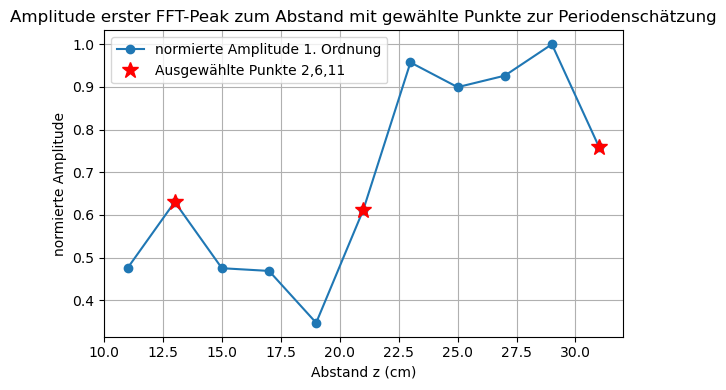

In [ ]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Benutze die aus der vorherigen Zelle bestimmten Werte: 'zs' und 'first_order_amplitudes'
try:
    zs_arr = np.array(zs)
    amps = np.array(first_order_amplitudes)
except NameError:
    raise NameError("Variable 'zs' oder 'first_order_amplitudes' nicht gefunden. Bitte vorherige Zelle ausführen.")

# Normiere die Amplitude (nur für Plot)
amps_norm = amps / np.max(amps)

# Spezifische Punkte verwenden: Punkt 2, 6 und 11 (vom Nutzer gewünscht). Diese sind 1-basiert.
selected = [2, 6, 11]  # 1-basiert
idxs = [s - 1 for s in selected]
if max(idxs) >= len(zs_arr):
    raise IndexError(f"Ausgewählte Messpunkte {selected} sind nicht alle vorhanden. Vorhandene Messpunkte: {len(zs_arr)}")

z2, z6, z11 = zs_arr[idxs[0]], zs_arr[idxs[1]], zs_arr[idxs[2]]
amp2, amp6, amp11 = amps[idxs[0]], amps[idxs[1]], amps[idxs[2]]

# Alternative Periodenschätzung: Finde die Maxima der Amplituden und berechne deren mittleren Abstand

# Finde Peaks in der normierten Amplitude
peak_idxs, _ = find_peaks(amps_norm, height=0.5)  # Threshold ggf. anpassen
z_peaks = zs_arr[peak_idxs]

if len(z_peaks) < 2:
    raise ValueError("Nicht genügend Peaks gefunden für Periodenschätzung.")

# Berechne die Abstände zwischen den Peaks
periods = np.diff(z_peaks)
zT_exp = periods.mean()
zT_exp_std = periods.std(ddof=1)

# Für die Ausgabe: Zeige die gefundenen Peak-Positionen und Perioden
#print(f"Gefundene Peak-Positionen (z in mm): {z_peaks}")
#print(f"Perioden zwischen Peaks (mm): {periods}")
#periods = np.array([p1, p2, p3])
#zT_exp = periods.mean()
#zT_exp_std = periods.std(ddof=1)

# Theoretische Talbot-Länge (anpassbare Werte)
a_mm = 0.125  # [mm] - passe an (z.B. 0.125 oder 0.25)
lambda_m = 636e-9  # [m] Laserwellenlänge
a_m = a_mm * 1e-3
zT_theo_m = 2 * a_m ** 2 / lambda_m
zT_theo_cm = zT_theo_m * 1e2

# Ausgabe
#print(f"Ausgewählte Messpunkte (z in mm): {selected} -> {[z2, z6, z11]}")
#print(f"Amplituden an diesen Punkten (a.u.): {[amp2, amp6, amp11]}")
#print(f"Periodenschätzungen (mm): p1={p1:.3f}, p2={p2:.3f}, p3={p3:.3f}")
print(f"Experimentelle Talbot-Länge (Mittel): {zT_exp:.3f} cm (Std {zT_exp_std:.3f})")
print(f"Theoretische Talbot-Länge (a = {a_mm} mm, λ = {lambda_m*1e9:.1f} nm): {zT_theo_cm:.3f} cm")
print(f"Relative Abweichung: {(zT_exp - zT_theo_cm)/zT_theo_cm*100:.1f} %")

# Plot: normierte Amplitude und markiere die gewählten Punkte
plt.figure(figsize=(6,4))
plt.plot(zs_arr, amps_norm, 'o-', label='normierte Amplitude 1. Ordnung')
plt.plot([z2, z6, z11], [amps_norm[idxs[0]], amps_norm[idxs[1]], amps_norm[idxs[2]]], 'r*', markersize=12, label='Ausgewählte Punkte 2,6,11')
plt.xlabel('Abstand z (cm)')
plt.ylabel('normierte Amplitude')
plt.title('Amplitude erster FFT-Peak zum Abstand mit gewählte Punkte zur Periodenschätzung')
plt.grid(True)
plt.legend()
plt.tight_layout()


## Fehlerbetrachtung
Da wir einne sehr großen relativen Fehler für die letzte Aufgabe erhalten lohnt es ich nochmal speziell anzuschauen wie man darauf kommen konnte.
Ein möglicher Grund für den sehr großen relativen Fehler (über 60 %) liegt darin, dass unsere Kamera viel Streulicht aufgenommen hat, da der Laser stark gestreut wurde. Dadurch waren im aufgenommenen Abbildungsbild keine klaren Muster erkennbar, was die Messung erheblich erschwert hat. Die Bestimmung der Talbot-Länge erfolgte daher nur grob, indem wir die Abstände zwischen den Messpunkten etwa auf eine halbe theoretische Talbot-Länge gelegt haben. Zudem war die Anzahl der Messpunkte mit nur 11 deutlich zu gering – mit etwa 50 Messpunkten hätte man die Oszillation der Amplitude wesentlich besser auflösen und den Einfluss von Rauschen deutlich reduzieren können. Mehr Datenpunkte wären also notwendig gewesen, um verlässlichere und genauere Ergebnisse zu erhalten.